In [1]:
!git clone https://github.com/AnanduDinesan/Facial-Expression-Recognition.git

Cloning into 'Facial-Expression-Recognition'...
remote: Enumerating objects: 34072, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 34072 (delta 2), reused 4 (delta 1), pack-reused 34059 (from 3)
Receiving objects: 100% (34072/34072), 52.84 MiB | 19.01 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Updating files: 100% (35889/35889), done.


# =========================
# SECTION 1 — UPLOAD DATASET
# =========================

In [2]:
DATASET_PATH = "/content/Facial-Expression-Recognition/data"
TRAIN_PATH   = DATASET_PATH + "/train"
TEST_PATH    = DATASET_PATH + "/test"

IMG_SIZE    = 48
BATCH_SIZE  = 64
NUM_CLASSES = 7
SEED        = 42

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [5]:

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.1,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# ==============================
# SECTION 2 — DATA ANALYSIS
# ==============================

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

Class distribution: {'disgust': 436, 'sad': 4830, 'fear': 4097, 'happy': 7215, 'surprise': 3171, 'angry': 3995, 'neutral': 4965}


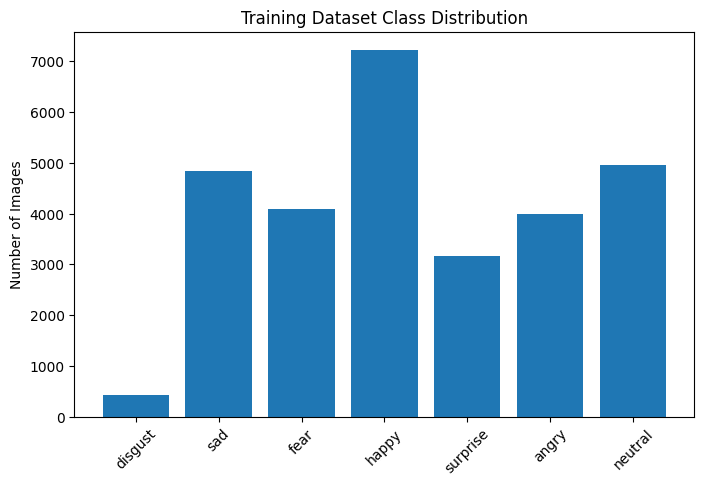

In [9]:
class_counts = {}

for cls in os.listdir(TRAIN_PATH):
    class_counts[cls] = len(os.listdir(os.path.join(TRAIN_PATH, cls)))

print("Class distribution:", class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

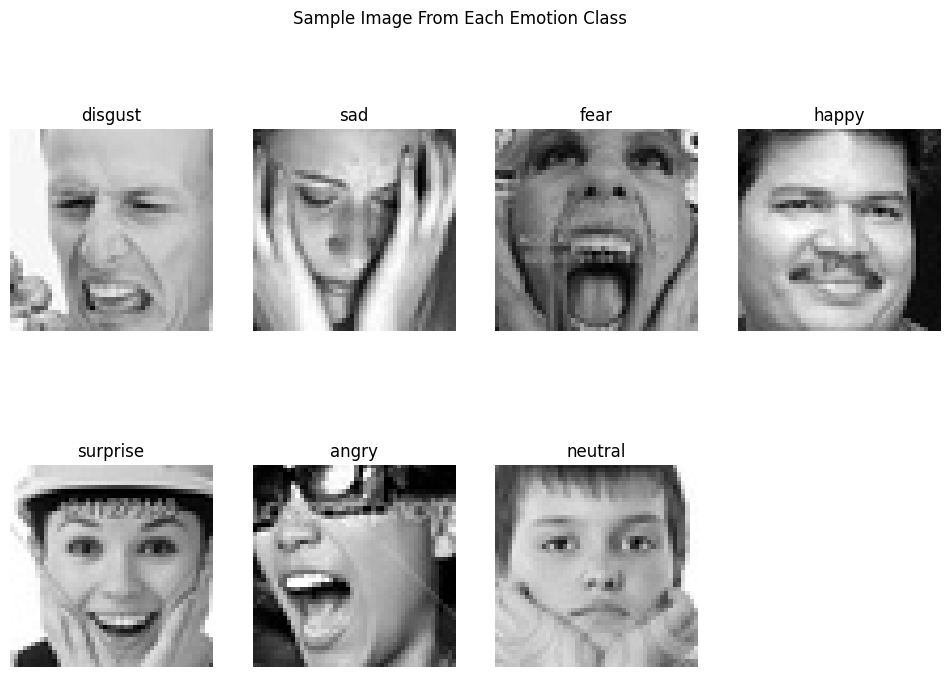

In [10]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(class_counts.keys()):
    folder = os.path.join(TRAIN_PATH, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = plt.imread(img_path)

    ax = plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Image From Each Emotion Class")
plt.show()

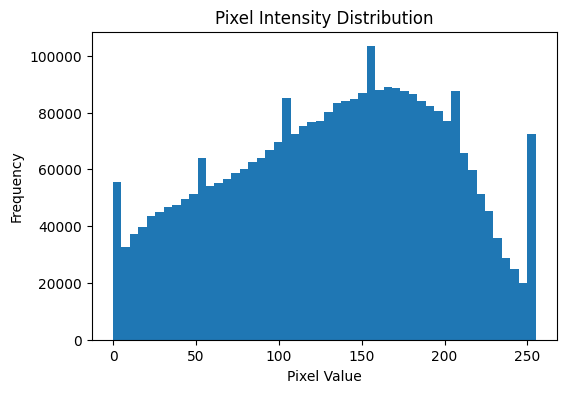

In [11]:
pixel_values = []

for cls in os.listdir(TRAIN_PATH):
    folder = os.path.join(TRAIN_PATH, cls)
    for img_name in os.listdir(folder)[:200]:
        img = plt.imread(os.path.join(folder, img_name))
        pixel_values.extend(img.flatten())

plt.figure(figsize=(6,4))
plt.hist(pixel_values, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [12]:
sizes = set()

for cls in os.listdir(TRAIN_PATH):
    folder = os.path.join(TRAIN_PATH, cls)
    for img_name in os.listdir(folder)[:50]:
        img = plt.imread(os.path.join(folder, img_name))
        sizes.add(img.shape)

print("Unique image sizes:", sizes)

Unique image sizes: {(48, 48)}


In [13]:
total_images = sum(class_counts.values())
num_classes = len(class_counts)

print(f"Total training images: {total_images}")
print(f"Number of emotion classes: {num_classes}")

Total training images: 28709
Number of emotion classes: 7


# =============================
# SECTION 3 — DATA PREPROCESSING
# =============================

In [14]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers
import numpy as np
import os

In [15]:
label_list = []

for i, cls in enumerate(class_names):
    folder = os.path.join(TRAIN_PATH, cls)
    label_list += [i] * len(os.listdir(folder))

label_list = np.array(label_list)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_list),
    y=label_list
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [16]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

train_val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.1,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

train_ds = train_val_ds_raw.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).cache().prefetch(tf.data.AUTOTUNE)

val_ds  = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

for images, labels_batch in train_ds.take(1):
    print("Batch shape  :", images.shape)
    print("Pixel range  : %.1f – %.1f" % (images.numpy().min(), images.numpy().max()))

Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.
Batch shape  : (64, 48, 48, 3)
Pixel range  : 0.0 – 255.0


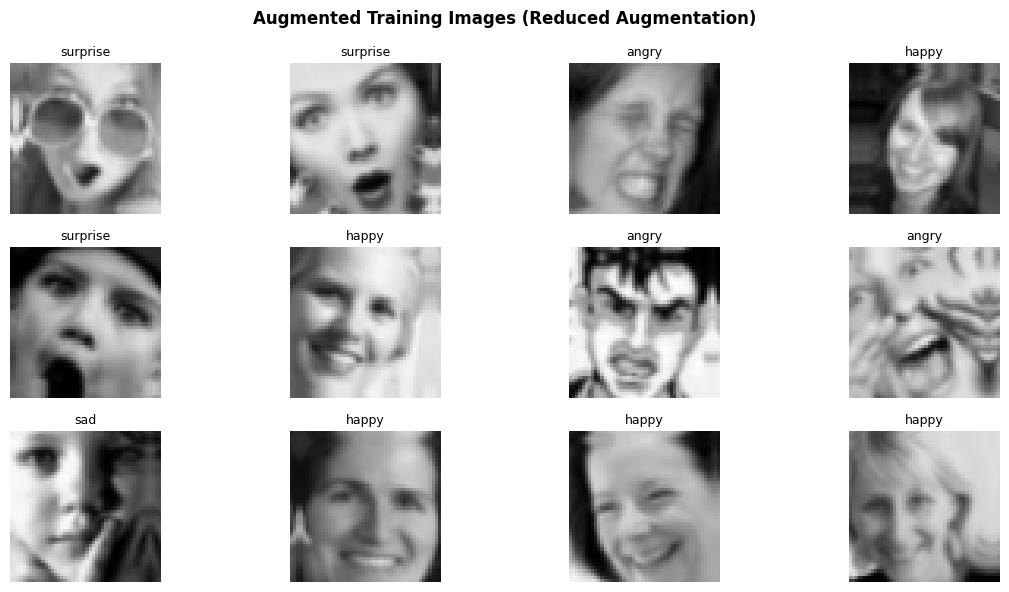

In [17]:
for images, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 6))
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i].numpy().argmax()], fontsize=9)
        plt.axis('off')
    plt.suptitle("Augmented Training Images (Reduced Augmentation)", fontweight='bold')
    plt.tight_layout()
    plt.show()
    break

# ==============================
# SECTION 4 — MODEL BUILDING
# ==============================

In [18]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
import os

In [19]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print(f'Base model layers     : {len(base_model.layers)}')
print(f'Trainable params      : {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}')
print(f'Non-trainable params  : {sum([tf.size(w).numpy() for w in base_model.non_trainable_weights])}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers     : 238
Trainable params      : 0
Non-trainable params  : 4049571


In [20]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='FER_EfficientNetB0')

model.summary()

Model: "FER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [21]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

print(f'Total params      : {model.count_params():,}')
print(f'Trainable params  : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

Total params      : 4,384,426
Trainable params  : 332,295


In [24]:
os.makedirs('checkpoints', exist_ok=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/best_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

In [22]:

print('PHASE 1 — Training classification head only')

PHASE1_EPOCHS = 30

history_phase1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks
)

print(f'\nPhase 1 complete!')
print(f'Best val accuracy : {max(history_phase1.history["val_accuracy"]):.4f}')
print(f'Final train acc   : {history_phase1.history["accuracy"][-1]:.4f}')

In [ ]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print(f'Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

print('\n' + '='*50)
print('PHASE 2 — Fine-tuning top layers of EfficientNetB0')
print('='*50)

PHASE2_EPOCHS = 50

history_phase2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks
)

print(f'\n Phase 2 complete!')
print(f'Best val accuracy : {max(history_phase2.history["val_accuracy"]):.4f}')

# ==============================
# SECTION 4 — MODEL BUILDING
# ==============================

In [47]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
MODEL_PATH = "fer_efficientnet_v2_final.keras"

model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "FER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,041,338 (30.68 MB)

 Trainable params: 1,828,455 (6.98 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

 Optimizer params: 3,656,912 (13.95 MB)

In [42]:
loss, acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {acc*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3337 - loss: 1.7297

Test Loss: 1.6405
Test Accuracy: 39.82%


In [44]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [46]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.29      0.31      0.30       958
     disgust       0.07      0.12      0.08       111
        fear       0.26      0.14      0.18      1024
       happy       0.52      0.60      0.55      1774
     neutral       0.38      0.35      0.37      1233
         sad       0.37      0.28      0.32      1247
    surprise       0.44      0.69      0.54       831

    accuracy                           0.40      7178
   macro avg       0.33      0.35      0.33      7178
weighted avg       0.39      0.40      0.38      7178



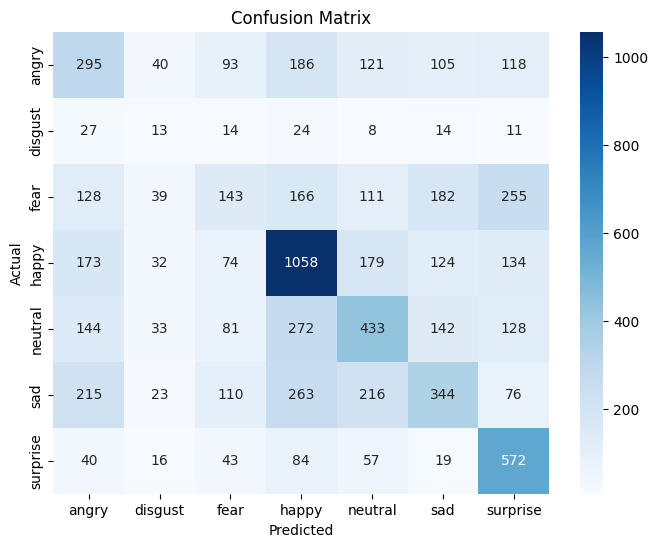

In [48]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:")
for i, acc in enumerate(class_acc):
    print(f"{class_names[i]} : {acc*100:.2f}%")


Per-class accuracy:
angry : 30.79%
disgust : 11.71%
fear : 13.96%
happy : 59.64%
neutral : 35.12%
sad : 27.59%
surprise : 68.83%
